## Plotting spring time series for event selection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.linear_model import LinearRegression
from scipy.signal import find_peaks

# tau
shear_stress_full = pd.read_csv('../data/shear_stress/average_total_shear_stress_corrected.csv', parse_dates=['datetime'], index_col='datetime')
# sonde data
down_sonde = pd.read_csv('../data/sonde_data/sonde_down_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
up_sonde = pd.read_csv('../data/sonde_data/sonde_up_full_record_smoothed.csv', parse_dates=['DateTime'], index_col='DateTime')
# nutrient data
down_constituents = pd.read_csv('../data/constituents/SP23_down_constituents.csv', parse_dates=['Date_Time'], index_col='Date_Time')
up_constituents = pd.read_csv('../data/constituents/SP23_up_constituents.csv', parse_dates=['Date_Time'], index_col='Date_Time')

# determine dates of spring: 
min_date = pd.Timestamp('2023-04-15')
max_date = pd.Timestamp('2023-05-09')

# filter data to spring period
tau = shear_stress_full.loc[(shear_stress_full.index >= min_date) & (shear_stress_full.index <= max_date)]
down_sonde = down_sonde.loc[(down_sonde.index >= min_date) & (down_sonde.index <= max_date)]
up_sonde = up_sonde.loc[(up_sonde.index >= min_date) & (up_sonde.index <= max_date)]

# in sonde data sets, delete rows with negative data 
down_sonde = down_sonde[(down_sonde['Turbidity FNU'] >= 0) & (down_sonde['fDOM RFU'] >= 0) & (down_sonde['fDOM RFU'] <= 2)]
up_sonde = up_sonde[(up_sonde['Turbidity FNU'] >= 0) & (up_sonde['fDOM RFU'] >= 0) & (up_sonde['fDOM RFU'] <= 3)]

Turbidity Time Series

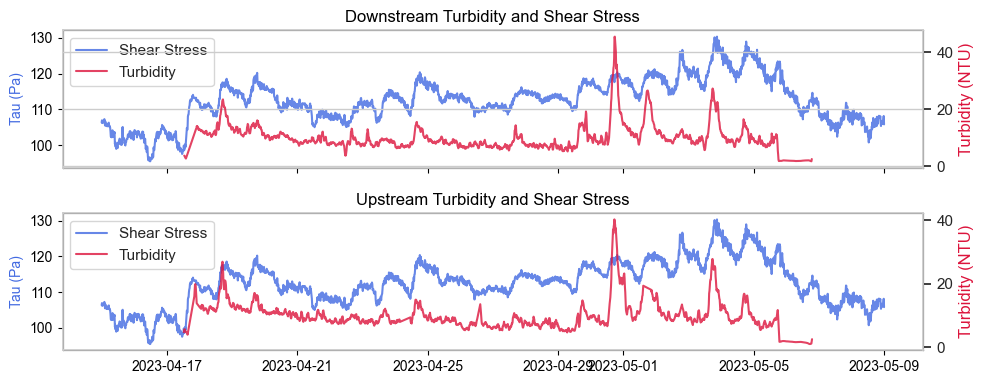

In [3]:
# plot tau and turbidity time series for reaches
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")
colors = ['royalblue', 'crimson']
labels = ['Shear Stress', 'Turbidity']
ylabels = ['Tau (Pa)', 'Turbidity (NTU)']
data = [down_sonde, up_sonde]
titles = ['Downstream Turbidity and Shear Stress', 'Upstream Turbidity and Shear Stress']

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau['shear_stress'], label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(False)

    ax_turb.plot(sonde.index, sonde['Turbidity FNU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    ax_tau.set_title(titles[i])
    lines, labs = ax_tau.get_legend_handles_labels()
    lines2, labs2 = ax_turb.get_legend_handles_labels()
    ax_tau.legend(lines + lines2, labs + labs2, loc='upper left')

plt.grid(False)
plt.tight_layout()
plt.show()

fDOM Time Series

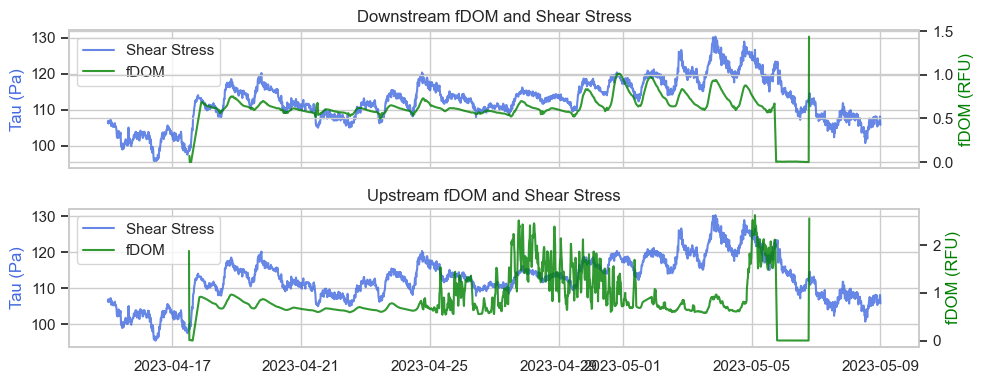

In [4]:
# plot tau and turbidity time series for reaches
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
sns.set_theme(style="whitegrid")
colors = ['royalblue', 'green']
labels = ['Shear Stress', 'fDOM']
ylabels = ['Tau (Pa)', 'fDOM (RFU)']
data = [down_sonde, up_sonde]
titles = ['Downstream fDOM and Shear Stress', 'Upstream fDOM and Shear Stress']

for i, sonde in enumerate(data):
    ax_tau = ax[i]
    ax_turb = ax_tau.twinx()

    ax_tau.plot(tau.index, tau['shear_stress'], label=labels[0], color=colors[0], alpha=0.8)
    ax_tau.set_ylabel(ylabels[0], color=colors[0])
    ax_tau.grid(True)

    ax_turb.plot(sonde.index, sonde['fDOM RFU'], label=labels[1], color=colors[1], alpha=0.8)
    ax_turb.set_ylabel(ylabels[1], color=colors[1])

    ax_tau.set_title(titles[i])
    lines, labs = ax_tau.get_legend_handles_labels()
    lines2, labs2 = ax_turb.get_legend_handles_labels()
    ax_tau.legend(lines + lines2, labs + labs2, loc='upper left')

plt.grid(False)
plt.tight_layout()
plt.show()

Determining event peaks

In [5]:
# resample discharge to 1 min to have matching time steps with sonde data 
tau_resampled = tau.resample('1min').interpolate()
# merge shear stress to the sonde dataframe 
down_sonde = down_sonde.merge(tau_resampled, left_index=True, right_index=True, how='left')
up_sonde = up_sonde.merge(tau_resampled, left_index=True, right_index=True, how='left')

up_sonde

,Turbidity FNU,fDOM RFU,shear_stress
DateTime,,,
2023-04-17 12:29:00,4.774567,1.877722,99.781269
2023-04-17 12:44:00,5.592353,0.010305,98.649383
2023-04-17 12:59:00,5.686188,0.008818,98.998976
2023-04-17 13:14:00,5.725505,0.010098,99.113353
2023-04-17 13:29:00,5.349801,0.008423,100.156806
...,...,...,...
2023-05-06 17:59:00,1.121984,0.000000,112.495492
2023-05-06 18:14:00,1.169017,0.000000,112.622849
2023-05-06 18:29:00,1.206398,0.000000,112.079504


In [6]:
# tau is second column
tau = down_sonde['shear_stress']
# smooth slightly
tau_smooth = tau.rolling(6, center=True).mean()

# find peaks
peak_idx, _ = find_peaks(
    tau_smooth,
    prominence=3,   # adjust
    distance=12     # adjust based on timestep
)

peak_times = tau_smooth.index[peak_idx]
events = []

for peak in peak_idx:
    # search backward for local minimum
    left = peak
    while left > 0 and tau_smooth.iloc[left-1] <= tau_smooth.iloc[left]:
        left -= 1

    # search forward for local minimum
    right = peak
    while right < len(tau_smooth)-1 and tau_smooth.iloc[right+1] <= tau_smooth.iloc[right]:
        right += 1

    events.append({
        'start': tau_smooth.index[left],
        'peak': tau_smooth.index[peak],
        'end': tau_smooth.index[right],
        'peak_tau': tau_smooth.iloc[peak]
    })

events = pd.DataFrame(events)

print(events)

                 start                peak                 end    peak_tau
0  2023-04-17 13:33:00 2023-04-17 22:18:00 2023-04-18 01:33:00  112.550851
1  2023-04-18 19:18:00 2023-04-18 20:18:00 2023-04-18 22:33:00  117.492991
2  2023-04-19 17:33:00 2023-04-19 18:03:00 2023-04-19 19:48:00  119.152946
3  2023-04-21 16:33:00 2023-04-21 18:33:00 2023-04-21 20:03:00  109.406011
4  2023-04-22 23:03:00 2023-04-22 23:18:00 2023-04-23 00:18:00  112.212730
5  2023-04-23 18:48:00 2023-04-23 20:18:00 2023-04-23 21:18:00  115.079453
6  2023-04-24 10:48:00 2023-04-24 17:48:00 2023-04-24 18:18:00  119.222878
7  2023-04-27 17:48:00 2023-04-27 20:48:00 2023-04-27 22:33:00  115.360935
8  2023-04-29 19:48:00 2023-04-29 20:18:00 2023-04-29 21:48:00  118.055768
9  2023-04-30 19:33:00 2023-04-30 19:48:00 2023-05-01 00:18:00  119.770220
10 2023-05-01 23:03:00 2023-05-01 23:33:00 2023-05-02 00:18:00  120.030707
11 2023-05-02 18:48:00 2023-05-02 19:33:00 2023-05-02 22:18:00  125.179952
12 2023-05-03 11:33:00 20